# Final Homework Project: The Complete ML Pipeline

**Topics:** Data Preprocessing · Linear & Logistic Regression · Neural Networks · Clustering

**Team Size**: 1–3 students (individual or group)
**Submission**: This single `.ipynb` file, fully executed, uploaded to Canvas
**Due Date**: July 31, 11:59 PM
**Total Points**: 100

---

## Group Members

> **Replace this line with your name(s) and Panther ID(s).** For groups, every member submits the same notebook and leaves a submission comment on Canvas listing all members.

---

## Project Overview

In this project you will carry **one dataset** — student exam performance records — through the *entire* machine learning pipeline:

1. **Preprocess** the raw data (it contains real-world quality issues).
2. **Regression**: predict `exam_score` with linear/polynomial regression.
3. **Classification**: predict `passed` with logistic regression.
4. **Neural networks**: build a 2-layer MLP from scratch and verify every gradient by hand.
5. **Unsupervised learning**: hide the labels, cluster the students, then check whether the clusters rediscover the pass/fail structure.

Throughout, you work at **two levels**:

- **Level 1 — NumPy (from scratch)**: translate the math from lecture into code so you understand *what* the model learns and *how* optimization works.
- **Level 2 — Industry tools (PyTorch / scikit-learn)**: verify your from-scratch results and learn the tools you will use in practice. Small numerical differences between levels are expected and fine.

**Do everything once, reuse it everywhere.** You preprocess the data once in Part 1 and reuse it in Parts 2, 3, and 5. You implement `sigmoid` and cross-entropy once in Part 3 and reuse them in Part 4. Plan accordingly.

---

## Dataset

Two CSV files (see the accompanying dataset description for column definitions):

- `train.csv` — training data (~326 rows). **Contains data quality issues** you must find and handle.
- `test.csv` — clean data for ~80 **unseen students, features only (no targets)** — it simulates students whose outcomes are not yet known. You will apply your preprocessing to it and generate predictions; all quantitative evaluation (MSE, accuracy) uses a **validation split you create from the training data**. Never use test.csv to fit preprocessing parameters.

The dataset description tells you what each column *means*, not which columns to *use* — that decision is yours to make and justify.

---

## Grading

Each part is graded on two tiers: **Completion** (you attempted the task and produced reasonable, visible outputs) and **Quality** (correct results, clear reasoning, insightful analysis).

| Part | Completion | Quality | Total |
|---|---|---|---|
| 1. Data Preprocessing | 9 | 6 | **15** |
| 2. Linear Regression | 12 | 8 | **20** |
| 3. Logistic Regression | 9 | 6 | **15** |
| 4. Neural Network From Scratch | 12 | 8 | **20** |
| 5. Unsupervised Learning | 12 | 8 | **20** |
| 6. Summary & Reflection | 6 | 4 | **10** |
| **Total** | **60** | **40** | **100** |

**Grading philosophy:** a student who diligently completes every task earns ~60/100 from Completion alone; thorough work with good analysis lands in the 80–90 range.

## Submission Requirements

1. **Restart kernel → Run All** before submitting. Cells without visible output receive zero credit for that task.
2. All plots inline, with titles, axis labels, and legends.
3. Keep all existing cells: do not rename, reorder, or delete the section headers, the checkpoint cells, or the answer placeholder cells — grading is parsed by them. You are free to **add** as many new code or markdown cells as you like within any section.
4. Name the file `FinalProject_LastName.ipynb` (groups: `FinalProject_LastName1_LastName2.ipynb`).

## AI Tool Policy

You may use AI tools to assist with coding and debugging. However, all **analysis, interpretation, and written discussion must demonstrate your own understanding**. A follow-up review may be conducted for any submission; if asked, you should be able to explain every line of your submitted code and the reasoning behind your analysis. Submissions that cannot be explained during such a review may receive a zero.

---
# 0. Imports and Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

np.random.seed(42)
torch.manual_seed(42)

train_df = pd.read_csv('/train.csv')
test_df = pd.read_csv('/test.csv')
print(f"train: {train_df.shape},  test: {test_df.shape}")

train: (326, 8),  test: (80, 8)


---
# 1. Data Preprocessing (15 points)

You clean and prepare the data **once**, here. Every later part uses the result.

## 1.1 Exploratory Data Analysis — 5 pts

**Completion (3):**
- Display basic statistics: shape, dtypes, `.describe()`, `.info()`.
- Identify and report every data quality issue you find (missing values, duplicates, impossible values, outliers).
- Produce **at least 3 visualizations**: feature distributions (histograms/box plots) and feature–target relationships (scatter plots vs. `exam_score`).

**Quality (2):**
- Describe each issue's potential impact on model training.
- Thorough exploration that catches *all* major issues.

In [3]:
# === 1.1 EDA ===

# Display the number of rows and columns
print("Training data shape:")
print(train_df.shape)

# Display the first five rows
print("\nFirst five rows:")
display(train_df.head())

# Display each column's data type
print("\nColumn data types:")
display(train_df.dtypes.to_frame(name="Data Type"))

# Display detailed dataset information
print("\nDataset information:")
train_df.info()

# Display descriptive statistics
print("\nDescriptive statistics:")
display(train_df.describe().T)

Training data shape:
(326, 8)

First five rows:


,student_id,hours_studied,sleep_hours,attendance_rate,prev_exam_score,lucky_number,exam_score,passed
0,3006,7.96,10.99,41.23,66.79,23,56.85,0
1,1097,6.79,7.52,60.92,NaN,67,61.18,0
2,1194,14.17,9.92,25.45,88.79,59,86.88,1
3,1093,10.61,5.21,31.49,54.38,16,55.11,0
4,1164,7.14,5.24,40.16,58.11,1,60.49,1



Column data types:


,Data Type
student_id,int64
hours_studied,float64
sleep_hours,float64
attendance_rate,float64
prev_exam_score,float64
lucky_number,int64
exam_score,float64
passed,int64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   student_id       326 non-null    int64  
 1   hours_studied    310 non-null    float64
 2   sleep_hours      310 non-null    float64
 3   attendance_rate  310 non-null    float64
 4   prev_exam_score  310 non-null    float64
 5   lucky_number     326 non-null    int64  
 6   exam_score       309 non-null    float64
 7   passed           326 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 20.5 KB

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
student_id,326.0,1194.420245,264.490578,1001.00,1082.2500,1163.500,1244.7500,3006.00
hours_studied,310.0,7.656645,4.547264,-5.00,3.9800,8.005,11.4250,30.00
sleep_hours,310.0,7.496258,2.596727,3.10,5.2700,7.540,9.7600,12.00
attendance_rate,310.0,56.055968,28.806831,-10.00,31.0875,57.255,79.0350,200.00
prev_exam_score,310.0,57.214161,16.763007,20.07,43.2325,55.430,71.5075,94.27
lucky_number,326.0,50.328221,29.232115,1.00,26.0000,50.000,77.0000,99.00
exam_score,309.0,64.856084,19.349312,-20.00,50.9600,66.340,79.7000,150.00
passed,326.0,0.579755,0.494357,0.00,0.0000,1.000,1.0000,1.00


In [5]:
# Missing-value summary
missing_summary = pd.DataFrame({
    "Missing Count": train_df.isna().sum(),
    "Missing Percentage": (
        train_df.isna().mean() * 100
    ).round(2)
})

print("Missing-value summary:")
display(missing_summary)


# Check exact duplicate rows
exact_duplicates = train_df.duplicated().sum()

print("\nExact duplicates including student_id:")
print(exact_duplicates)


# Check duplicates while ignoring the unique student ID
duplicate_columns = [
    column
    for column in train_df.columns
    if column != "student_id"
]

duplicate_count_without_id = train_df.duplicated(
    subset=duplicate_columns,
    keep="first"
).sum()

print("\nDuplicate records excluding student_id:")
print(duplicate_count_without_id)


# Show every row involved in a duplicate group
duplicate_mask = train_df.duplicated(
    subset=duplicate_columns,
    keep=False
)

print("\nRows involved in duplicate groups:")
display(
    train_df.loc[duplicate_mask]
    .sort_values(by=duplicate_columns)
)

Missing-value summary:


,Missing Count,Missing Percentage
student_id,0,0.00
hours_studied,16,4.91
sleep_hours,16,4.91
attendance_rate,16,4.91
prev_exam_score,16,4.91
lucky_number,0,0.00
exam_score,17,5.21
passed,0,0.00



Exact duplicates including student_id:
0

Duplicate records excluding student_id:
6

Rows involved in duplicate groups:


,student_id,hours_studied,sleep_hours,attendance_rate,prev_exam_score,lucky_number,exam_score,passed
56,3005,-3.00,11.55,18.95,71.56,65,85.38,1
316,1255,-3.00,11.55,18.95,71.56,65,85.38,1
113,1055,1.92,6.39,63.32,29.48,32,NaN,0
149,3002,1.92,6.39,63.32,29.48,32,NaN,0
26,3001,5.87,5.95,66.33,52.79,82,51.65,0
263,1147,5.87,5.95,66.33,52.79,82,51.65,0
0,3006,7.96,10.99,41.23,66.79,23,56.85,0
116,1116,7.96,10.99,41.23,66.79,23,56.85,0
50,3003,8.89,11.36,95.03,55.35,6,84.68,1
135,1049,8.89,11.36,95.03,55.35,6,84.68,1


In [6]:
# Check values that fall outside the documented ranges

documented_ranges = {
    "hours_studied": (0, 15),
    "sleep_hours": (3, 12),
    "attendance_rate": (0, 100),
    "prev_exam_score": (0, 100),
    "exam_score": (0, 100)
}

invalid_value_summary = []

for column, (minimum, maximum) in documented_ranges.items():

    invalid_mask = (
        train_df[column].notna()
        & ~train_df[column].between(
            minimum,
            maximum,
            inclusive="both"
        )
    )

    invalid_values = sorted(
        train_df.loc[invalid_mask, column].unique()
    )

    invalid_value_summary.append({
        "Column": column,
        "Valid Minimum": minimum,
        "Valid Maximum": maximum,
        "Invalid Count": int(invalid_mask.sum()),
        "Invalid Values": invalid_values
    })

print("Values outside documented ranges:")
display(pd.DataFrame(invalid_value_summary))


# Show the complete records containing invalid values
combined_invalid_mask = pd.Series(
    False,
    index=train_df.index
)

for column, (minimum, maximum) in documented_ranges.items():

    column_invalid_mask = (
        train_df[column].notna()
        & ~train_df[column].between(
            minimum,
            maximum,
            inclusive="both"
        )
    )

    combined_invalid_mask = (
        combined_invalid_mask | column_invalid_mask
    )

print("\nRows containing at least one invalid value:")
display(train_df.loc[combined_invalid_mask])

Values outside documented ranges:


,Column,Valid Minimum,Valid Maximum,Invalid Count,Invalid Values
0,hours_studied,0,15,5,"[-5.0, -3.0, 30.0]"
1,sleep_hours,3,12,0,[]
2,attendance_rate,0,100,3,"[-10.0, 150.0, 200.0]"
3,prev_exam_score,0,100,0,[]
4,exam_score,0,100,4,"[-20.0, -10.0, 150.0]"



Rows containing at least one invalid value:


,student_id,hours_studied,sleep_hours,attendance_rate,prev_exam_score,lucky_number,exam_score,passed
38,1243,-5.00,11.73,34.37,46.42,87,49.93,0
56,3005,-3.00,11.55,18.95,71.56,65,85.38,1
61,1145,2.54,5.57,23.97,30.89,75,-10.00,0
72,1225,14.12,6.82,-10.00,85.72,47,86.71,1
76,1197,10.86,4.63,96.01,55.57,42,-20.00,1
117,1067,-5.00,6.22,10.99,NaN,55,31.70,0
168,1242,1.34,6.50,200.00,38.22,51,47.73,1
194,1098,4.04,6.32,52.68,33.55,75,-10.00,0
274,1269,30.00,7.98,69.30,38.66,7,42.49,0
296,1229,NaN,8.56,150.00,40.10,52,55.62,0


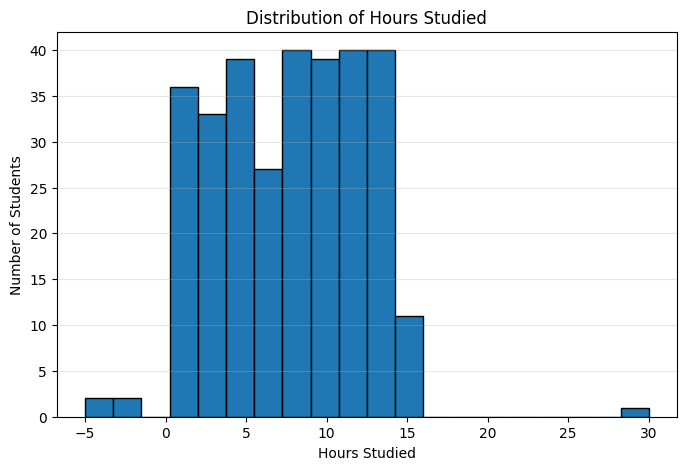

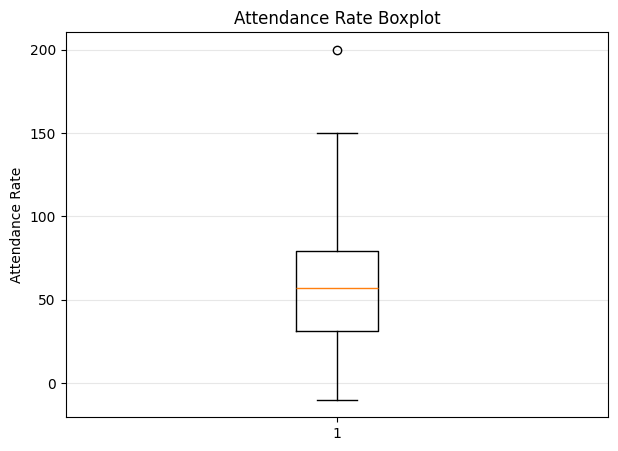

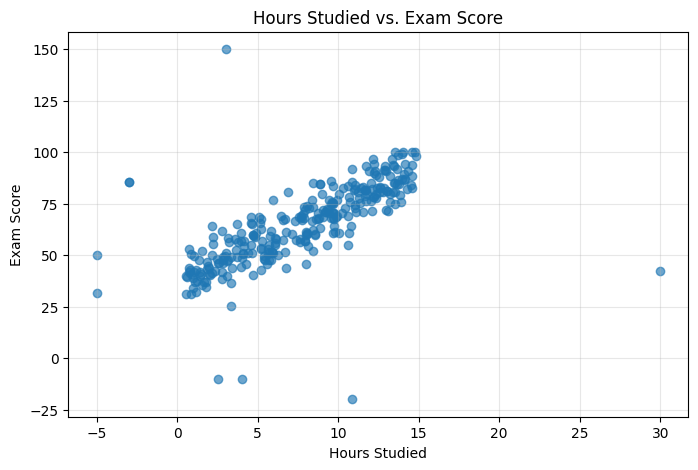

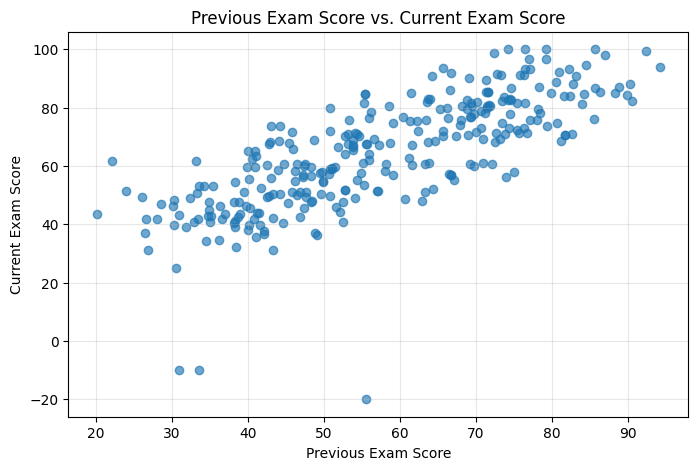

In [7]:
# Visualization 1: Distribution of hours studied
plt.figure(figsize=(8, 5))
plt.hist(
    train_df["hours_studied"].dropna(),
    bins=20,
    edgecolor="black"
)
plt.xlabel("Hours Studied")
plt.ylabel("Number of Students")
plt.title("Distribution of Hours Studied")
plt.grid(axis="y", alpha=0.3)
plt.show()


# Visualization 2: Attendance-rate boxplot
plt.figure(figsize=(7, 5))
plt.boxplot(
    train_df["attendance_rate"].dropna()
)
plt.ylabel("Attendance Rate")
plt.title("Attendance Rate Boxplot")
plt.grid(axis="y", alpha=0.3)
plt.show()


# Visualization 3: Hours studied vs. exam score
hours_score_data = train_df[
    ["hours_studied", "exam_score"]
].dropna()

plt.figure(figsize=(8, 5))
plt.scatter(
    hours_score_data["hours_studied"],
    hours_score_data["exam_score"],
    alpha=0.65
)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs. Exam Score")
plt.grid(alpha=0.3)
plt.show()


# Visualization 4: Previous exam score vs. current exam score
previous_score_data = train_df[
    ["prev_exam_score", "exam_score"]
].dropna()

plt.figure(figsize=(8, 5))
plt.scatter(
    previous_score_data["prev_exam_score"],
    previous_score_data["exam_score"],
    alpha=0.65
)
plt.xlabel("Previous Exam Score")
plt.ylabel("Current Exam Score")
plt.title("Previous Exam Score vs. Current Exam Score")
plt.grid(alpha=0.3)
plt.show()

**Your findings (1.1):** *I started by looking through the training data to see what problems were in it before doing any modeling. The dataset has 326 rows and 8 columns. I found missing values in hours_studied, sleep_hours, attendance_rate, and prev_exam_score. There were also 17 missing values in exam_score, which is important because that is the value the regression model is supposed to predict.
I also checked for duplicates. At first, it looked like there were none, but that was because every row had a different student_id. When I checked without the ID column, I found 6 duplicate records. I also found values that clearly did not make sense, such as negative study hours, attendance rates over 100%, and exam scores below 0 or above 100. The 30-hour study value also stood out because it was much higher than the normal range in the dataset description.
From the graphs, students who studied more usually had higher exam scores. Previous exam score also seemed to have a strong relationship with the current exam score. These patterns were pretty clear, but the bad values made some of the graphs look stretched, so the data needs to be cleaned before training the model.*

## 1.2 Data Cleaning — 5 pts

**Completion (3):** handle missing values, outliers/impossible values, and duplicates. Show **before/after row counts** for each step.

**Quality (2):** there is no single correct answer — what earns quality points is a brief, sound **justification for each decision** (why drop vs. impute, why this outlier rule, etc.).

In [8]:
# === 1.2 Cleaning ===

clean_df = train_df.copy()

print(f"Before cleaning: {len(clean_df)} rows")


# 1. Remove duplicate records
# student_id is ignored because duplicated records were given different IDs.
duplicate_columns = [
    column for column in clean_df.columns
    if column != "student_id"
]

rows_before = len(clean_df)

clean_df = clean_df.drop_duplicates(
    subset=duplicate_columns,
    keep="first"
).copy()

print(
    f"After removing duplicates: {len(clean_df)} rows "
    f"({rows_before - len(clean_df)} removed)"
)


# 2. Remove rows with missing or invalid exam scores
# exam_score is the regression target, so it should not be guessed or imputed.
rows_before = len(clean_df)

invalid_exam_score = (
    clean_df["exam_score"].isna()
    | ~clean_df["exam_score"].between(0, 100)
)

clean_df = clean_df.loc[
    ~invalid_exam_score
].copy()

print(
    f"After removing missing/invalid exam scores: "
    f"{len(clean_df)} rows "
    f"({rows_before - len(clean_df)} removed)"
)


# 3. Replace impossible or extreme feature values with NaN
# These will be imputed later using the training split only.
feature_ranges = {
    "hours_studied": (0, 15),
    "sleep_hours": (3, 12),
    "attendance_rate": (0, 100),
    "prev_exam_score": (0, 100)
}

for column, (minimum, maximum) in feature_ranges.items():

    invalid_mask = (
        clean_df[column].notna()
        & ~clean_df[column].between(
            minimum,
            maximum,
            inclusive="both"
        )
    )

    invalid_count = int(invalid_mask.sum())

    clean_df.loc[
        invalid_mask,
        column
    ] = np.nan

    print(
        f"{column}: {invalid_count} invalid values "
        f"changed to NaN"
    )


print(f"\nAfter cleaning: {len(clean_df)} rows")

print("\nMissing feature values remaining:")
display(
    clean_df[
        [
            "hours_studied",
            "sleep_hours",
            "attendance_rate",
            "prev_exam_score"
        ]
    ]
    .isna()
    .sum()
    .to_frame(name="Missing Count")
)

Before cleaning: 326 rows
After removing duplicates: 320 rows (6 removed)
After removing missing/invalid exam scores: 300 rows (20 removed)
hours_studied: 4 invalid values changed to NaN
sleep_hours: 0 invalid values changed to NaN
attendance_rate: 3 invalid values changed to NaN
prev_exam_score: 0 invalid values changed to NaN

After cleaning: 300 rows

Missing feature values remaining:


,Missing Count
hours_studied,19
sleep_hours,16
attendance_rate,17
prev_exam_score,15


**Your justifications (1.2):** *I removed the duplicate rows and any records with missing or invalid exam_score values because they can affect the results. Invalid feature values were changed to missing values so they can be filled later using the training data only.*

## 1.3 Feature Selection & Normalization — 5 pts

**Completion (3):**
- Decide which columns are legitimate input features. Should `lucky_number` be included? `student_id`? Justify every inclusion/exclusion.
- Compute and plot a **correlation matrix** to support your analysis.
- Apply **Z-score normalization** to the selected features. Show before/after mean and std. **Fit the parameters (mean, std) on training data only**, then apply the same transform to the validation and test data.
- Create a fixed-seed **80/20 train/validation split** of the cleaned training data. All "validation" metrics in Parts 2–3 use this split.

**Quality (2):**
- Explain why normalization matters for gradient descent *and* for distance-based clustering (Part 5). What goes wrong if `attendance_rate` ranges 40–100 while `sleep_hours` ranges 3–10?

Selected features:
['hours_studied', 'sleep_hours', 'attendance_rate', 'prev_exam_score']

Split sizes:
Training rows: 240
Validation rows: 60

Correlation matrix:


,student_id,hours_studied,sleep_hours,attendance_rate,prev_exam_score,lucky_number,exam_score,passed
student_id,1.00,-0.03,0.07,-0.03,0.08,-0.00,0.00,-0.04
hours_studied,-0.03,1.00,0.00,0.08,0.87,-0.01,0.89,0.72
sleep_hours,0.07,0.00,1.00,0.10,-0.10,0.03,0.23,0.14
attendance_rate,-0.03,0.08,0.10,1.00,0.15,-0.02,0.34,0.26
prev_exam_score,0.08,0.87,-0.10,0.15,1.00,0.00,0.80,0.64
lucky_number,-0.00,-0.01,0.03,-0.02,0.00,1.00,-0.00,0.03
exam_score,0.00,0.89,0.23,0.34,0.80,-0.00,1.00,0.79
passed,-0.04,0.72,0.14,0.26,0.64,0.03,0.79,1.00


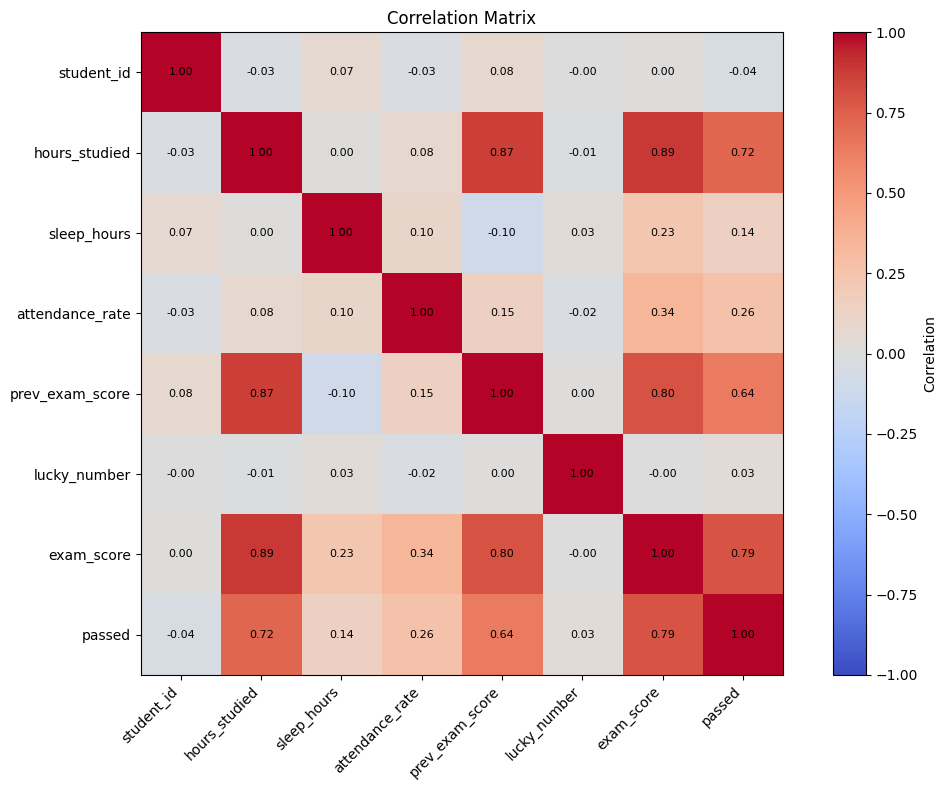


Training-set feature medians:


,Median
hours_studied,8.200
sleep_hours,7.560
attendance_rate,54.560
prev_exam_score,55.915



Normalization results:


,Before Mean,Before Std,After Mean,After Std
hours_studied,7.9104,3.9755,0.0,1.0
sleep_hours,7.4980,2.5234,-0.0,1.0
attendance_rate,54.5668,26.6763,0.0,1.0
prev_exam_score,57.5442,15.9399,0.0,1.0



Final array shapes:
X_tr: (240, 4)
X_val: (60, 4)
X_test: (80, 4)
y_reg_tr: (240,)
y_reg_val: (60,)
y_clf_tr: (240,)
y_clf_val: (60,)


In [9]:
# === 1.3 Feature selection & normalization ===

from sklearn.model_selection import train_test_split


# 1. Choose the input features
features = [
    "hours_studied",
    "sleep_hours",
    "attendance_rate",
    "prev_exam_score"
]

print("Selected features:")
print(features)


# 2. Make the fixed 80/20 split
# The same students will be used for regression and classification.
train_part, val_part = train_test_split(
    clean_df,
    test_size=0.20,
    random_state=42
)

print("\nSplit sizes:")
print("Training rows:", len(train_part))
print("Validation rows:", len(val_part))


# 3. Correlation matrix
# This uses only the training portion to avoid using validation information.
correlation_columns = [
    "student_id",
    "hours_studied",
    "sleep_hours",
    "attendance_rate",
    "prev_exam_score",
    "lucky_number",
    "exam_score",
    "passed"
]

correlation_matrix = train_part[
    correlation_columns
].corr()

print("\nCorrelation matrix:")
display(correlation_matrix.round(2))


# Plot the correlation heatmap
plt.figure(figsize=(11, 8))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

for row in range(len(correlation_columns)):
    for column in range(len(correlation_columns)):
        plt.text(
            column,
            row,
            f"{correlation_matrix.iloc[row, column]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


# 4. Fill missing feature values
# Medians are calculated from the training portion only.
feature_medians = train_part[features].median()

X_tr_raw = (
    train_part[features]
    .fillna(feature_medians)
    .to_numpy(dtype=float)
)

X_val_raw = (
    val_part[features]
    .fillna(feature_medians)
    .to_numpy(dtype=float)
)


# Use only the selected feature columns from test.csv.
# Do not use exam_score or passed from the uploaded test file.
test_features_df = test_df[features].copy()

X_test_raw = (
    test_features_df
    .fillna(feature_medians)
    .to_numpy(dtype=float)
)


# 5. Create regression and classification targets
y_reg_tr = train_part["exam_score"].to_numpy(dtype=float)
y_reg_val = val_part["exam_score"].to_numpy(dtype=float)

y_clf_tr = train_part["passed"].to_numpy(dtype=float)
y_clf_val = val_part["passed"].to_numpy(dtype=float)


# 6. Calculate normalization values from training data only
mu = X_tr_raw.mean(axis=0)
sigma = X_tr_raw.std(axis=0)

# Prevent division by zero if a feature has no variation.
sigma = np.where(sigma == 0, 1, sigma)


# 7. Apply the same normalization to all three sets
X_tr = (X_tr_raw - mu) / sigma
X_val = (X_val_raw - mu) / sigma
X_test = (X_test_raw - mu) / sigma


# 8. Save preprocessing information for the team
preprocessing_info = {
    "features": features,
    "medians": feature_medians.to_numpy(),
    "mean": mu,
    "standard_deviation": sigma
}


# 9. Show the before-and-after statistics
normalization_summary = pd.DataFrame({
    "Before Mean": X_tr_raw.mean(axis=0),
    "Before Std": X_tr_raw.std(axis=0),
    "After Mean": X_tr.mean(axis=0),
    "After Std": X_tr.std(axis=0)
}, index=features)

print("\nTraining-set feature medians:")
display(feature_medians.to_frame(name="Median"))

print("\nNormalization results:")
display(normalization_summary.round(4))

print("\nFinal array shapes:")
print("X_tr:", X_tr.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_reg_tr:", y_reg_tr.shape)
print("y_reg_val:", y_reg_val.shape)
print("y_clf_tr:", y_clf_tr.shape)
print("y_clf_val:", y_clf_val.shape)# === 1.3 Feature selection & normalization ===
# TODO: correlation matrix + heatmap

# TODO: choose features, with reasoning
# features = [...]

# TODO: z-score normalization — fit on train only
# mu, sigma = ...

# TODO: fixed-seed 80/20 train/validation split of the cleaned data
# X_tr, X_val = ...          # normalized feature arrays
# y_reg_tr, y_reg_val = ...  # exam_score targets
# y_clf_tr, y_clf_val = ...  # passed targets
# X_test = ...               # test.csv features (normalized with TRAIN mu/sigma) — predictions only, no labels

# print before/after statistics

**Your reasoning (1.3):** *I kept the four columns that relate to studying and past performance, and left out student_id and lucky_number because they do not provide meaningful academic information. I normalized the features so that columns with larger values would not have more influence on gradient descent or clustering.*

---
# 2. Linear Regression (20 points)

**Target:** `exam_score` (continuous). Use the cleaned, normalized features from Part 1.

## 2.1 NumPy Implementation — 10 pts

Implement linear regression with gradient descent **using only NumPy**:

**Completion (6):**
- MSE cost: $J(\beta) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$
- Gradient computation for all parameters (lecture formulas).
- Gradient descent update loop with configurable learning rate.
- Plot the **loss curve** (MSE vs. iteration).
- Report final parameters and final **train/validation MSE**.
- Apply the trained model to `test.csv` and display the first 5 predicted exam scores (these students have no ground truth — this is what deployment looks like).

**Quality (4):** correct gradients, converging loss, clean code with comments on the gradient math.

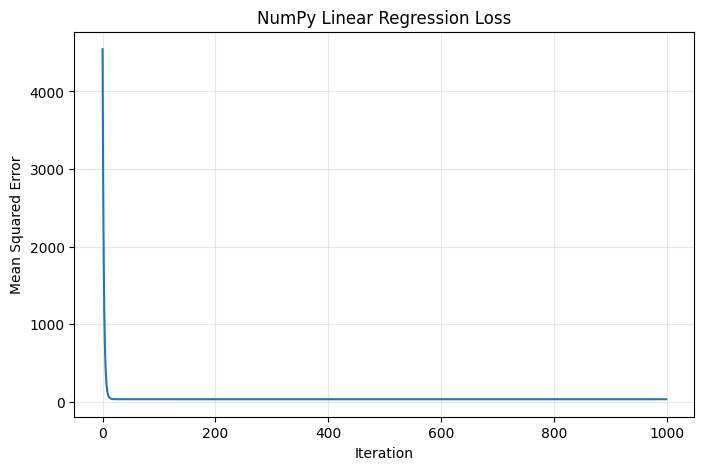

Final model parameters:


,Parameter,Value
0,intercept,65.2854
1,hours_studied,10.4824
2,sleep_hours,3.8824
3,attendance_rate,3.8416
4,prev_exam_score,4.5534


Final training MSE: 35.4935
Final validation MSE: 33.1028

First five test predictions:


,student_id,predicted_exam_score
0,2001,41.11
1,2002,64.77
2,2003,38.98
3,2004,86.33
4,2005,83.27


In [10]:
# === 2.1 Linear regression from scratch ===

def mse_loss(y_true, y_pred):
    """Calculate mean squared error."""
    return np.mean((y_true - y_pred) ** 2)


def add_intercept(X):
    """Add a column of ones for the intercept."""
    return np.column_stack([
        np.ones(X.shape[0]),
        X
    ])


def linreg_gradients(X, y, beta):
    """Return the gradient of MSE for all parameters."""

    X_with_intercept = add_intercept(X)

    predictions = X_with_intercept @ beta
    errors = predictions - y

    n = len(y)

    # Gradient of MSE:
    # (2 / n) * X.T * (predictions - actual values)
    gradient = (
        2 / n
    ) * X_with_intercept.T @ errors

    return gradient


def train_linreg(X, y, lr=0.1, iters=1000):
    """Train linear regression using gradient descent."""

    X_with_intercept = add_intercept(X)

    # One intercept plus one coefficient for each feature
    beta = np.zeros(X_with_intercept.shape[1])

    loss_history = []

    for iteration in range(iters):

        predictions = X_with_intercept @ beta
        loss = mse_loss(y, predictions)

        loss_history.append(loss)

        gradient = linreg_gradients(
            X,
            y,
            beta
        )

        beta -= lr * gradient

    return beta, loss_history


# Train the model
beta_numpy, loss_history = train_linreg(
    X_tr,
    y_reg_tr,
    lr=0.1,
    iters=1000
)


# Plot the training loss
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.title("NumPy Linear Regression Loss")
plt.grid(alpha=0.3)
plt.show()


# Make training and validation predictions
train_predictions = (
    add_intercept(X_tr) @ beta_numpy
)

validation_predictions = (
    add_intercept(X_val) @ beta_numpy
)


# Calculate final MSE values
train_mse_numpy = mse_loss(
    y_reg_tr,
    train_predictions
)

validation_mse_numpy = mse_loss(
    y_reg_val,
    validation_predictions
)


# Display the learned parameters
parameter_names = [
    "intercept"
] + features

parameter_table = pd.DataFrame({
    "Parameter": parameter_names,
    "Value": beta_numpy
})

print("Final model parameters:")
display(parameter_table.round(4))

print(
    f"Final training MSE: "
    f"{train_mse_numpy:.4f}"
)

print(
    f"Final validation MSE: "
    f"{validation_mse_numpy:.4f}"
)


# Predict the exam scores for test.csv
test_predictions_numpy = (
    add_intercept(X_test) @ beta_numpy
)

first_five_test_predictions = pd.DataFrame({
    "student_id": test_df["student_id"].iloc[:5],
    "predicted_exam_score":
        test_predictions_numpy[:5]
})

print("\nFirst five test predictions:")
display(
    first_five_test_predictions.round(2)
)

## 2.2 PyTorch Verification — 5 pts

**Completion (3):** same model with `torch.nn.Linear`, `torch.nn.MSELoss`, and `torch.optim.SGD`; train and plot the loss curve.

**Quality (2):** a **side-by-side table** of NumPy vs. PyTorch parameters and MSE, with a sentence on whether they agree and why small differences are expected.

In [ ]:
# === 2.2 PyTorch verification ===
# TODO: define, train, plot, compare with 2.1

## 2.3 Polynomial Regression — 5 pts

**Completion (3):** train polynomial regression (NumPy or PyTorch) for degree = **2, 5, 10**; report a table of train MSE and validation MSE per degree; plot the fitted curves on one figure.

**Quality (2):** identify which degree generalizes best (lowest validation MSE) and where **overfitting/underfitting** begins; relate to the bias–variance discussion from lecture.

In [ ]:
# === 2.3 Polynomial regression ===
# TODO: degrees 2, 5, 10 -> train/validation MSE table + overlay plot

**Your analysis (2.3):** *Replace with your overfitting/underfitting discussion.*

---
# 3. Logistic Regression (15 points)

**Target:** `passed` (binary). Same features as Part 2.

You will implement `sigmoid`, `sigmoid_derivative`, and binary cross-entropy here — **Part 4 reuses these functions**, so get them right (the checkpoint below verifies them).

## 3.1 NumPy Implementation — 8 pts

**Completion (5):**
- Sigmoid: $\sigma(z) = \frac{1}{1+e^{-z}}$, and its derivative $\sigma'(z) = \sigma(z)(1-\sigma(z))$. Verify against the checkpoint.
- Cross-entropy cost: $J(\beta) = -\frac{1}{n}\sum_i [y_i\log(\sigma(z_i)) + (1-y_i)\log(1-\sigma(z_i))]$
- Gradient computation + update rule; train and plot the loss curve.
- Predictions with threshold $T=0.5$; report **train and validation accuracy**.

**Quality (3):** correct gradients, converging loss, commented code.

In [ ]:
# === 3.1a Sigmoid + BCE (REUSED IN PART 4) ===
def sigmoid(z):
    # TODO
    pass

def sigmoid_derivative(z):
    # TODO: use sigmoid()
    pass

def bce_loss(y_true, y_hat):
    """Binary cross-entropy for a single sample or array."""
    eps = 1e-8  # avoid log(0)
    # TODO
    pass

In [ ]:
# === Print Checkpoint: sigmoid ===
for z in [-2, -1, 0, 1, 2, 3, 5]:
    print(f"sigma({z:2d}) = {sigmoid(z):.4f},  sigma'({z:2d}) = {sigmoid_derivative(z):.4f}")

**Reference output** (your printout should agree with these values):
```
sigma(-2) = 0.1192,  sigma'(-2) = 0.1050
sigma(-1) = 0.2689,  sigma'(-1) = 0.1966
sigma( 0) = 0.5000,  sigma'( 0) = 0.2500
sigma( 1) = 0.7311,  sigma'( 1) = 0.1966
sigma( 2) = 0.8808,  sigma'( 2) = 0.1050
sigma( 3) = 0.9526,  sigma'( 3) = 0.0452
sigma( 5) = 0.9933,  sigma'( 5) = 0.0066
```

In [ ]:
# === 3.1b Logistic regression from scratch ===
def train_logreg(X, y, lr=0.1, iters=1000):
    # TODO: gradient descent with sigmoid + BCE; return (beta, loss_history)
    pass

# TODO: train, plot loss curve, report train/validation accuracy at T=0.5

## 3.2 PyTorch Verification — 4 pts

**Completion (2):** same model with `torch.nn.BCEWithLogitsLoss` (or `BCELoss` + sigmoid) and a PyTorch optimizer.

**Quality (2):** side-by-side comparison of validation accuracy and parameters with your NumPy results.

In [ ]:
# === 3.2 PyTorch verification ===
# TODO

## 3.3 Threshold Analysis — 3 pts

**Completion (2):** report validation accuracy at thresholds $T = 0.3, 0.5, 0.7$.

**Quality (1):** when might you deliberately use a threshold other than 0.5? And: why is cross-entropy more appropriate than MSE for classification?

In [ ]:
# === 3.3 Thresholds ===
# TODO: accuracy at T = 0.3, 0.5, 0.7

**Your discussion (3.3):** *Replace with your threshold and loss-function discussion.*

---
# 4. Neural Network From Scratch (20 points)

You will now build a **2-input, 2-hidden, 1-output MLP** using only NumPy — no sklearn, no PyTorch. To make every intermediate number verifiable against the lecture slides, this part uses the small 10-student dataset from class. Your `sigmoid`, `sigmoid_derivative`, and `bce_loss` from Part 3 are reused directly.

In [ ]:
# The 10-student toy dataset from lecture (x1 = hours studied, x2 = sleep hours)
X_toy = np.array([
    [1, 5], [2, 6], [3, 4], [4, 7], [5, 8],
    [6, 7], [7, 8], [8, 3], [9, 6], [10, 4]
], dtype=float)

y_toy = np.array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1], dtype=float)

student_names = ['A','B','C','D','E','F','G','H','I','J']
print(f"Toy dataset: {len(X_toy)} students")

## 4.1 Forward Pass — 5 pts

**Completion (3):** implement `forward()` returning all intermediate values (`z1, h1, z2, h2, zo, y_hat`). Run the checkpoint with the lecture weights.

**Quality (2):** all 10 students classified correctly (10/10) with the lecture weights; clean, commented code.

In [ ]:
def forward(x, weights):
    """
    x: array (2,) — one data point [x1, x2]
    weights: dict with keys 'w11','w12','b1','w21','w22','b2','v1','v2','bo'
    Returns dict with 'z1','h1','z2','h2','zo','y_hat'
    """
    # Hidden neuron 1
    z1 = None  # TODO
    h1 = None  # TODO
    # Hidden neuron 2
    z2 = None  # TODO
    h2 = None  # TODO
    # Output neuron
    zo = None  # TODO
    y_hat = None  # TODO
    return {'z1': z1, 'h1': h1, 'z2': z2, 'h2': h2, 'zo': zo, 'y_hat': y_hat}

In [ ]:
# === Print Checkpoint: forward pass with lecture weights ===
weights = {
    'w11': 1, 'w12': 0, 'b1': -3,
    'w21': 0, 'w22': 1, 'b2': -6,
    'v1': 1, 'v2': 1, 'bo': -1
}

print(f"{'Student':>8} {'x1':>4} {'x2':>4} | {'z1':>5} {'h1':>7} {'z2':>5} {'h2':>7} | {'y_hat':>7} {'Pred':>5} {'True':>5}")
print("-" * 75)
for i in range(len(X_toy)):
    r = forward(X_toy[i], weights)
    pred = 1 if r['y_hat'] >= 0.5 else 0
    mark = 'O' if pred == y_toy[i] else 'X'
    print(f"{student_names[i]:>8} {X_toy[i,0]:4.0f} {X_toy[i,1]:4.0f} | "
          f"{r['z1']:5.1f} {r['h1']:7.4f} {r['z2']:5.1f} {r['h2']:7.4f} | "
          f"{r['y_hat']:7.4f} {pred:5d} {int(y_toy[i]):5d} {mark}")

**Expected:** all 10 students classified correctly (10/10 accuracy).

## 4.2 Backward Pass — 8 pts

Compute the gradients of the BCE loss w.r.t. **all 9 parameters** for one data point, by applying the chain rule step by step.

**Completion (5):** implement `backward()`; run the Student F checkpoint.

**Quality (3):** every gradient agrees with the reference values below. If `dv1` matches, your output layer is right; if not, re-check the chain rule one step at a time.

In [ ]:
def backward(x, y_true, fwd, weights):
    """Returns dict of gradients for all 9 parameters (one data point)."""
    # Step 1: output error
    dL_dzo = None  # TODO: y_hat - y

    # Step 2: output layer gradients
    dL_dv1 = None  # TODO
    dL_dv2 = None  # TODO
    dL_dbo = None  # TODO

    # Step 3: propagate to hidden layer
    dL_dh1 = None  # TODO
    dL_dh2 = None  # TODO

    # Step 4: through sigmoid
    dL_dz1 = None  # TODO: dL_dh1 * sigmoid_derivative(fwd['z1'])
    dL_dz2 = None  # TODO

    # Step 5: hidden layer weight gradients
    dL_dw11 = None  # TODO
    dL_dw12 = None  # TODO
    dL_db1  = None  # TODO
    dL_dw21 = None  # TODO
    dL_dw22 = None  # TODO
    dL_db2  = None  # TODO

    return {
        'dv1': dL_dv1, 'dv2': dL_dv2, 'dbo': dL_dbo,
        'dw11': dL_dw11, 'dw12': dL_dw12, 'db1': dL_db1,
        'dw21': dL_dw21, 'dw22': dL_dw22, 'db2': dL_db2
    }

In [ ]:
# === Print Checkpoint: backward pass, Student F (6, 7), y=1 ===
fwd_F = forward(X_toy[5], weights)
grad_F = backward(X_toy[5], y_toy[5], fwd_F, weights)

print(f"y_hat = {fwd_F['y_hat']:.4f}, loss = {bce_loss(y_toy[5], fwd_F['y_hat']):.4f}")
print(f"Output error (dL/dzo): {fwd_F['y_hat'] - y_toy[5]:.4f}")
print(f"sigma'(z1) = {sigmoid_derivative(fwd_F['z1']):.4f}")
print(f"sigma'(z2) = {sigmoid_derivative(fwd_F['z2']):.4f}")
print("\nGradients:")
for name, val in grad_F.items():
    print(f"  {name:5s} = {val: .4f}")

**Reference gradients** (use these to verify your implementation; agreement to ~4 decimal places is expected):
```
dv1   = -0.3195
dv2   = -0.2452
dbo   = -0.3355
dw11  = -0.0909
dw12  = -0.1061
db1   = -0.0152
dw21  = -0.3957
dw22  = -0.4617
db2   = -0.0660
```

## 4.3 Training Loop — 5 pts

**Completion (3):** complete the weight-update step, train from random initialization, print progress every 100 epochs, plot the **loss curve**, and print final weights + final predictions for all 10 students.

**Quality (2):** loss decreases; sensible discussion if accuracy is below 10/10 (a 2-hidden-neuron network may not separate everything — that is okay).

In [ ]:
def train_mlp(X, y, lr=0.5, epochs=1000):
    """Train the 2-2-1 MLP from random initialization. Returns (weights, loss_history)."""
    np.random.seed(42)
    w = {
        'w11': np.random.randn()*0.5, 'w12': np.random.randn()*0.5, 'b1': 0.0,
        'w21': np.random.randn()*0.5, 'w22': np.random.randn()*0.5, 'b2': 0.0,
        'v1':  np.random.randn()*0.5, 'v2':  np.random.randn()*0.5, 'bo': 0.0
    }
    loss_history = []
    for epoch in range(epochs):
        total_loss = 0
        grad_sum = {k: 0.0 for k in ['dv1','dv2','dbo','dw11','dw12','db1','dw21','dw22','db2']}
        for i in range(len(X)):
            fwd = forward(X[i], w)
            total_loss += bce_loss(y[i], fwd['y_hat'])
            grad = backward(X[i], y[i], fwd, w)
            for k in grad_sum:
                grad_sum[k] += grad[k]
        for k in grad_sum:
            grad_sum[k] /= len(X)

        # TODO: update all 9 weights, e.g. w['w11'] -= lr * grad_sum['dw11']

        avg_loss = total_loss / len(X)
        loss_history.append(avg_loss)
        if epoch % 100 == 0 or epoch == epochs - 1:
            correct = sum(1 for i in range(len(X))
                          if (forward(X[i], w)['y_hat'] >= 0.5) == y[i])
            print(f"Epoch {epoch:4d} | Loss: {avg_loss:.4f} | Accuracy: {correct}/{len(X)}")
    return w, loss_history

final_weights, losses = train_mlp(X_toy, y_toy, lr=0.5, epochs=1000)

# TODO: print final weights, final predictions per student, and plot the loss curve

## 4.4 Observation Questions — 2 pts

Answer in this cell (2–3 sentences each):

**(a)** Compare the printed $\sigma'(z_1)$ and $\sigma'(z_2)$ values from the 4.2 checkpoint. Which neuron receives the smaller gradient? What problem does this illustrate, and which activation function would mitigate it?

**(b)** Does the loss curve from 4.3 decrease smoothly? Did the network reach 10/10? If not, why might a 2-hidden-neuron network struggle?

*Your answers:*

---
# 5. Unsupervised Learning (20 points)

Now pretend the labels never existed. Take your cleaned, normalized **training features from Part 1** (features only — no `exam_score`, no `passed`) and discover structure with clustering. Only in **5.4** are you allowed to bring `passed` back as ground truth.

**Do not touch the `passed` column until 5.4** — using it earlier defeats the purpose of unsupervised learning.

## 5.1 K-Means From Scratch — 8 pts

Implement K-Means **using only NumPy**, following the 4-step algorithm from lecture: initialize K centroids → assign each point to the nearest centroid (Euclidean) → recompute centroids as cluster means → repeat until convergence.

**Completion (5):**
- `kmeans_numpy(X, k, max_iters=100, random_state=42)` returning `(centroids, labels, wcss_history)`.
- Run with **K=2**; print final centroid coordinates and cluster sizes.
- Plot **WCSS across iterations** to show convergence.
- Verify with `sklearn.cluster.KMeans`: how many points are assigned differently? (Small differences are expected — sklearn uses `n_init=10`.)

**Quality (3):**
- Handle empty clusters gracefully.
- Interpret each centroid in terms of the original (un-normalized) features — e.g., "Cluster 0 = high study hours, high attendance."


In [ ]:
# === 5.1 K-Means from scratch ===
def kmeans_numpy(X, k, max_iters=100, random_state=42):
    # TODO
    pass

# TODO: run K=2, print centroids + cluster sizes, plot WCSS history
# TODO: compare with sklearn KMeans

**Your centroid interpretation (5.1):** *Replace with what each cluster appears to represent.*

## 5.2 Elbow Method — 4 pts

**Completion (2):** run K-Means (sklearn is fine) for K = 1–8, record WCSS (inertia), plot the elbow curve, and state your chosen K.

**Quality (2):** explain why WCSS always decreases as K grows (what happens at K = N?), and whether the elbow here is clear or ambiguous.

,K,WCSS
0,1,960.00
1,2,638.09
2,3,529.50
3,4,445.55
4,5,394.68
5,6,338.33
6,7,300.15
7,8,267.06


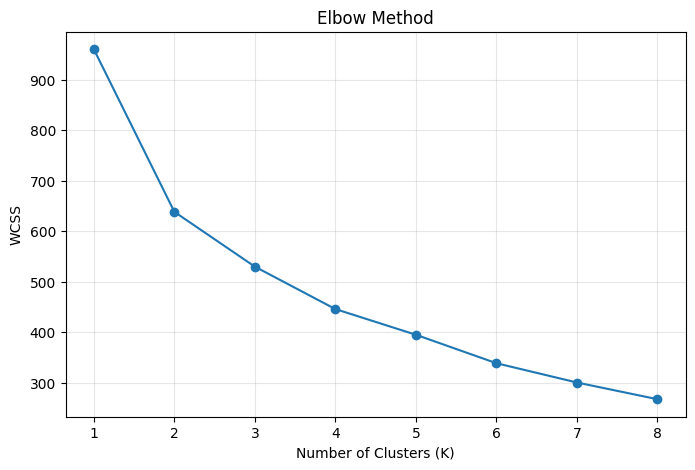

Chosen number of clusters: 2


In [11]:
# === 5.2 Elbow ===

k_values = range(1, 9)
wcss_values = []

for k in k_values:

    kmeans_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans_model.fit(X_tr)

    wcss_values.append(
        kmeans_model.inertia_
    )


# Display the WCSS values
elbow_results = pd.DataFrame({
    "K": list(k_values),
    "WCSS": wcss_values
})

display(elbow_results.round(2))


# Plot the elbow curve
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    wcss_values,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.show()


chosen_k = 2

print("Chosen number of clusters:", chosen_k)

## 5.3 Hierarchical Clustering & DBSCAN — 4 pts

**Completion (2):**
- Agglomerative clustering with **Ward's linkage** (`scipy.cluster.hierarchy.linkage` + `dendrogram`); plot the dendrogram and state how many clusters your chosen cut produces.
- Run `sklearn.cluster.DBSCAN` with at least **3 different `eps` values** (`min_samples=5`); for each, report number of clusters, number of noise points, and largest cluster size.

**Quality (2):**
- Does the dendrogram agree with your elbow-method K?
- Pick 2–3 noise points and explain *why* DBSCAN flagged them — are they true outliers or boundary students? What is the tradeoff when `eps` is too small vs. too large?

In [ ]:
# === 5.3 Hierarchical + DBSCAN ===
# TODO: Ward dendrogram + cut

# TODO: DBSCAN eps sweep -> summary table

**Your comparison (5.3):** *Replace with your dendrogram/elbow comparison and noise-point analysis.*

## 5.4 Cluster vs. Ground Truth — 4 pts

**Now** bring back the `passed` labels for the same (cleaned) training rows.

**Completion (2):**
- Cross-tabulate your K-Means (K=2) cluster labels against `passed`.
- Compute the percentage of students whose cluster aligns with their pass/fail label.
- Side-by-side scatter plots (same 2D feature pair): colored by cluster vs. colored by true label.

**Quality (2):** did K-Means "discover" pass/fail without seeing labels? Why is the alignment imperfect — what puts a student in the "wrong" cluster? When would you prefer unsupervised methods even when labels exist?

In [ ]:
# === 5.4 Ground truth comparison ===
# TODO: crosstab, alignment %, side-by-side scatter

**Your discussion (5.4):** *Replace with your alignment analysis.*

---
# 6. Summary & Reflection (10 points)

Write **300–500 words** in the cell below covering:

- Which preprocessing decisions had the biggest downstream impact — on the regression models *and* on clustering?
- Compare your from-scratch implementations (gradient descent, backprop, K-Means) with the library versions. What did implementing from scratch teach you that the libraries hide?
- The same sigmoid/BCE machinery appeared in logistic regression and the MLP. What is the relationship between the two models?
- What was the most challenging part, and how did you resolve it?
- If you had more time, what would you try next?

**Requirement:** this section must be written entirely in your own words and demonstrate genuine engagement with *your* results. It is evaluated for originality and depth; generic summaries receive zero.

*Your summary here (300–500 words):*

---
# Appendix: Results Summary (required)

Fill in your final values and run this cell **last**. Keep the exact `key: value` format — it is parsed during grading. If a value does not apply (e.g., you couldn't finish a task), write `NA`.

In [ ]:
# === RESULTS SUMMARY — do not change the keys or format ===
print("rows_before_cleaning:", None)         # TODO e.g. 326
print("rows_after_cleaning:", None)          # TODO
print("selected_features:", None)            # TODO e.g. ['hours_studied', ...]
print("linreg_numpy_val_MSE:", None)         # TODO (Part 2.1)
print("linreg_pytorch_val_MSE:", None)       # TODO (Part 2.2)
print("best_poly_degree:", None)             # TODO (Part 2.3)
print("logreg_numpy_val_acc:", None)         # TODO at T=0.5 (Part 3.1)
print("logreg_pytorch_val_acc:", None)        # TODO (Part 3.2)
print("mlp_final_toy_accuracy:", None)       # TODO e.g. '9/10' (Part 4.3)
print("kmeans_k2_cluster_sizes:", None)      # TODO e.g. [180, 120] (Part 5.1)
print("elbow_chosen_K:", None)               # TODO (Part 5.2)
print("dbscan_best_eps:", None)              # TODO (Part 5.3)
print("cluster_vs_passed_alignment_pct:", None)  # TODO (Part 5.4)